# 노트북 07 — 실제로 동작할까?

스트레스 테스트를 돌리고, FIPS 203 크기 표를 확인하며, 벤치마크를 수행합니다.

In [1]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt
from pqc_edu.params import ML_KEM_512, ML_KEM_768, ML_KEM_1024, ALL
from pqc_edu.ml_kem import ml_kem_keygen, ml_kem_encaps, ml_kem_decaps, _ml_kem_keygen_from_seeds

## 왕복(roundtrip) 스트레스 테스트 — 파라미터 집합당 200회 반복

복호화 실패는 0이어야 합니다.

In [2]:
iters = 200
for p in ALL:
    fails = 0
    for _ in range(iters):
        ek, dk = ml_kem_keygen(p)
        K1, ct = ml_kem_encaps(p, ek)
        K2 = ml_kem_decaps(p, dk, ct)
        if K1 != K2:
            fails += 1
    print(f"{p.name}: {iters - fails}/{iters} matched, {fails} failure(s)")

ML-KEM-512: 200/200 matched, 0 failure(s)


ML-KEM-768: 200/200 matched, 0 failure(s)


ML-KEM-1024: 200/200 matched, 0 failure(s)


## 크기 표 vs FIPS 203 Table 3

In [3]:
print(f"{'name':13} {'ek':>6} {'ct':>6} {'K':>3}   FIPS 203 Table 3")
print('-' * 52)
for p in ALL:
    ek, dk = ml_kem_keygen(p)
    _, ct = ml_kem_encaps(p, ek)
    print(f"{p.name:13} {len(ek):>6} {len(ct):>6} {32:>3}   matches={len(ek)==p.ek_bytes and len(ct)==p.ct_bytes}")

name              ek     ct   K   FIPS 203 Table 3
----------------------------------------------------
ML-KEM-512       800    768  32   matches=True
ML-KEM-768      1184   1088  32   matches=True
ML-KEM-1024     1568   1568  32   matches=True


## 결정성(determinism): 같은 시드는 반드시 같은 키를 생성해야 합니다

In [4]:
d = b'\xaa' * 32
z = b'\xbb' * 32
ek1, dk1 = _ml_kem_keygen_from_seeds(ML_KEM_768, d, z)
ek2, dk2 = _ml_kem_keygen_from_seeds(ML_KEM_768, d, z)
print('identical ek:', ek1 == ek2)
print('identical dk:', dk1 == dk2)

identical ek: True
identical dk: True


## 벤치마크 — 파라미터 집합당, 연산당 30회 반복

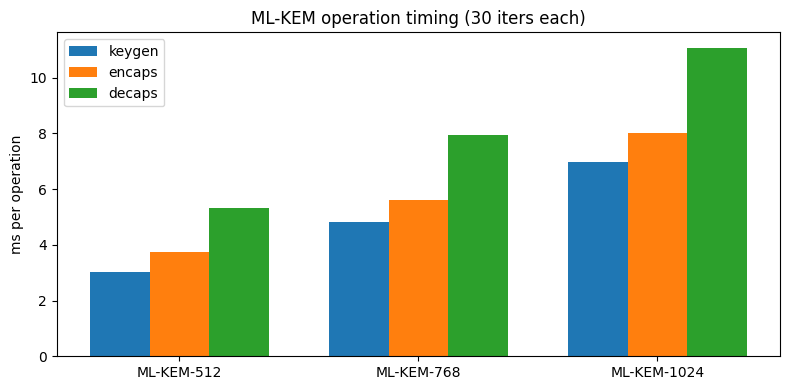


timing (ms):
  ML-KEM-512: keygen=3.0, encaps=3.7, decaps=5.3
  ML-KEM-768: keygen=4.8, encaps=5.6, decaps=8.0
  ML-KEM-1024: keygen=7.0, encaps=8.0, decaps=11.1


In [5]:
iters = 30
ops = ['keygen', 'encaps', 'decaps']
results = {p.name: {} for p in ALL}
for p in ALL:
    # keygen
    t0 = time.time()
    eks_dks = [ml_kem_keygen(p) for _ in range(iters)]
    results[p.name]['keygen'] = (time.time() - t0) / iters
    # encaps
    ek_sample, dk_sample = eks_dks[0]
    t0 = time.time()
    pairs = [ml_kem_encaps(p, ek_sample) for _ in range(iters)]
    results[p.name]['encaps'] = (time.time() - t0) / iters
    # decaps
    K_sample, ct_sample = pairs[0]
    t0 = time.time()
    for _ in range(iters):
        ml_kem_decaps(p, dk_sample, ct_sample)
    results[p.name]['decaps'] = (time.time() - t0) / iters

# Plot
names = [p.name for p in ALL]
x = np.arange(len(names))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
for i, op in enumerate(ops):
    vals = [results[n][op] * 1000 for n in names]
    ax.bar(x + (i - 1) * width, vals, width, label=op)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('ms per operation')
ax.set_title(f'ML-KEM operation timing ({iters} iters each)')
ax.legend(); plt.tight_layout(); plt.show()

print('\ntiming (ms):')
for n in names:
    print(f"  {n}: " + ', '.join(f"{op}={results[n][op]*1000:.1f}" for op in ops))

주의: 이것은 순수 Python 교육용 구현입니다. 상수 인수(최적화된 C 대비 약 1000배 느림)가 k=2/3/4의 알고리즘적 차이를 압도합니다. 그러나 전체 패턴(FO 재암호화 때문에 decaps ≈ keygen + encaps)은 여전히 보여야 합니다.